In [1]:
# === SESSION BOOTSTRAP ===
from google.colab import drive
drive.mount('/content/drive')
import os, subprocess, sys
PARENT="/content/drive/MyDrive/UAV_TRUST_Research"; REPO=f"{PARENT}/uav-trust-research"
for fn in (".gitconfig",".git-credentials"):
    p=os.path.join(PARENT,fn)
    if os.path.exists(p): subprocess.run(f'cp "{p}" /root/{fn}',shell=True)
subprocess.run("git config --global credential.helper store",shell=True)
if os.path.isdir(REPO):
    os.chdir(REPO); sys.path.insert(0,REPO) if REPO not in sys.path else None; print("cwd:",os.getcwd())
else: print("run 00_setup first")

Mounted at /content/drive
cwd: /content/drive/MyDrive/UAV_TRUST_Research/uav-trust-research


In [ ]:
!pip install xgboost scikit-learn matplotlib pandas numpy scipy pyarrow requests --quiet

In [ ]:
# Sequential monitoring v2: CUSUM change-detectors on coverage and error, fairly matched.
# Tests whether the coverage alarm fires EARLIER than the error alarm when an unseen family enters.
DATASETS=[
 {"name":"UAVIDS-2025","kind":"zenodo","record":"15336998","data_dir":"data/uavids2025",
  "label_col":"label","normal_value":"Normal Traffic","include_families":None,"subsample_n":None,
  "drops":["unnamed","flowid","srcaddr","dstaddr","srcport","dstport","index","timestamp"]},
 {"name":"UAV-NIDD","kind":"file","file":"data/uav_nidd/UAV-NDD CSV/UAV-Case1-Label.csv",
  "parquet":"data/uav_nidd/case1.parquet","data_dir":"data/uav_nidd","label_col":"Label",
  "normal_value":"Normal","include_families":["DDoS","UDP Flooding","MITM","Jamming","BruteForce","De-authentication"],
  "subsample_n":200000,
  "drops":["unnamed","index","ip.src","ip.dst","ip.proto","wlan.tag","srcport","dstport","udp.srcport","udp.dstport",
           "frame.time","frame.number","time_epoch","time_relative","time_delta","bssid","mactime",
           "vendor_oui","wlan_radio.timestamp","wlan_radio.start_tsf","radiotap.timestamp","wlan.seq"]},
]
CFG={"seeds":list(range(8)),"alpha":0.10,
     "normal_fracs":{"train":0.60,"cal":0.20,"test_seen":0.10,"test_shift":0.10},
     "family_fracs":{"train":0.60,"cal":0.20,"test_seen":0.20},
     "xgb":{"n_estimators":300,"max_depth":6,"learning_rate":0.1,"subsample":0.9,"colsample_bytree":0.9,"tree_method":"hist"},
     # --- stream + CUSUM design (shared by both monitors; calibrated on burn-in only) ---
     "window":50,           # small window -> many burn-in windows for stable baseline
     "burn_in":6000,        # long seen-only prefix
     "post_len":4000,       # steps after changepoint
     "ramp_len":2000,       # gradual mode: unseen fraction 0->1 over these steps
     "cusum_k_sd":0.5,      # CUSUM slack = 0.5 * burn-in SD of the signal (standard choice)
     "cusum_h_sd":5.0,      # CUSUM alarm threshold = 5 * burn-in SD (same multiplier for both monitors)
     "fig_dir":"figures","report_dir":"reports"}
for d in [CFG["fig_dir"],CFG["report_dir"]]: os.makedirs(d,exist_ok=True)
print("configured")

configured


In [ ]:
import numpy as np, pandas as pd, requests, glob, zipfile, importlib, gc, src.data
importlib.reload(src.data)
import matplotlib.pyplot as plt, xgboost as xgb
from src.data import load_csvs, detect_schema, prepare_splits
from src.trust import conformal_qhat

def load_dataset(spec):
    dd=spec["data_dir"]; os.makedirs(dd,exist_ok=True)
    if spec["kind"]=="zenodo":
        if not glob.glob(dd+"/**/*.csv",recursive=True):
            meta=requests.get(f"https://zenodo.org/api/records/{spec['record']}",timeout=60).json()
            for f in meta.get("files",[]):
                n,u=f["key"],f["links"]["self"]
                if n.lower().endswith((".csv",".zip",".gz")): open(os.path.join(dd,n),"wb").write(requests.get(u,timeout=1200).content)
            for z in glob.glob(dd+"/*.zip"): zipfile.ZipFile(z).extractall(dd)
        df=load_csvs(dd); lc,nv,fams=detect_schema(df,spec["label_col"],spec["normal_value"])
    else:
        pq=spec.get("parquet")
        df=pd.read_parquet(pq) if pq and os.path.exists(pq) else pd.read_csv(spec["file"],low_memory=False,encoding="latin-1")
        lc,nv=spec["label_col"],spec["normal_value"]; fams=[v for v in df[lc].unique() if v!=nv]
    if spec.get("subsample_n") and len(df)>spec["subsample_n"]:
        df=df.groupby(lc,group_keys=False).sample(frac=spec["subsample_n"]/len(df),random_state=42).reset_index(drop=True)
    if spec.get("include_families"):
        df=df[df[lc].isin([nv]+list(spec["include_families"]))].reset_index(drop=True); fams=list(spec["include_families"])
    return df,lc,nv,fams

def cusum_first_alarm(x, mu, sd, k_sd, h_sd, direction):
    """One-sided CUSUM. direction='up' detects an increase (error rate), 'down' a decrease (coverage).
    Slack k and threshold h are in units of burn-in SD, identical for both monitors."""
    if sd<=1e-9: sd=1e-9
    k=k_sd*sd; h=h_sd*sd; S=0.0
    for i,v in enumerate(x):
        d = (v-mu) if direction=="up" else (mu-v)
        S = max(0.0, S + d - k)
        if S>h: return i
    return None
print("helpers ready")

helpers ready


In [ ]:
# Build a stream, run BOTH CUSUM monitors with baselines fixed on the burn-in segment.
def run_stream(pool_seen_normal, pool_seen_atk, pool_unseen, p_of, qhat, rng, mode):
    W,BI,PL,RL=CFG["window"],CFG["burn_in"],CFG["post_len"],CFG["ramp_len"]
    draw=lambda pool,n: pool[rng.integers(0,len(pool),size=n)]
    bi=np.concatenate([draw(pool_seen_normal,BI//2), draw(pool_seen_atk,BI-BI//2)]); rng.shuffle(bi)
    rows=[]; isatk=[]
    for t in range(PL):
        if rng.random()<0.5:
            rows.append(pool_seen_normal[rng.integers(0,len(pool_seen_normal))]); isatk.append(0)
        else:
            frac = 1.0 if mode=="sharp" else min(1.0, t/max(1,RL))
            src = pool_unseen if rng.random()<frac else pool_seen_atk
            rows.append(src[rng.integers(0,len(src))]); isatk.append(1)
    stream=np.concatenate([bi,np.array(rows)]); y=np.array([0]*BI+isatk)
    p=p_of(stream); pred=(p>=0.5).astype(int)
    err=(pred!=y).astype(float)
    covered=np.where(y==1, ((1-p)<=qhat).astype(int), (p<=qhat).astype(int)).astype(float)
    roll=lambda a:(np.cumsum(np.insert(a,0,0))[W:]-np.cumsum(np.insert(a,0,0))[:-W])/W
    err_r=roll(err); cov_r=roll(covered)
    nb=BI-W  # burn-in windows
    # baselines (mean, sd) from burn-in windows ONLY; same for both monitors
    e_mu,e_sd=err_r[:nb].mean(),err_r[:nb].std(); c_mu,c_sd=cov_r[:nb].mean(),cov_r[:nb].std()
    cp=BI-W
    e_hit=cusum_first_alarm(err_r[cp:], e_mu, e_sd, CFG["cusum_k_sd"], CFG["cusum_h_sd"], "up")
    c_hit=cusum_first_alarm(cov_r[cp:], c_mu, c_sd, CFG["cusum_k_sd"], CFG["cusum_h_sd"], "down")
    return c_hit, e_hit
print("stream runner ready")

stream runner ready


In [ ]:
rows=[]
for spec in DATASETS:
    df,lc,nv,fams=load_dataset(spec); print(spec["name"],"loaded",len(df))
    for F in fams:
        for seed in CFG["seeds"]:
            S=prepare_splits(df,lc,nv,F,spec["drops"],CFG["normal_fracs"],CFG["family_fracs"],seed)
            for k in ["X_train","X_cal","X_seen","X_shift"]: S[k]=S[k].astype(np.float32)
            clf=xgb.XGBClassifier(objective="binary:logistic",eval_metric="logloss",random_state=seed,**CFG["xgb"]).fit(S["X_train"],S["y_train"])
            qhat=conformal_qhat(clf.predict_proba(S["X_cal"])[:,1], S["y_cal"], alpha=CFG["alpha"])
            p_of=lambda X: clf.predict_proba(X)[:,1]
            sn=S["X_seen"][S["fam_seen"]==nv]; sa=S["X_seen"][S["fam_seen"]!=nv]; un=S["X_shift"][S["fam_shift"]==F]
            if len(sn)<50 or len(sa)<50 or len(un)<50: del S,clf; gc.collect(); continue
            for mode in ["sharp","gradual"]:
                rng=np.random.default_rng(1000*seed+(0 if mode=="sharp" else 1))
                c_hit,e_hit=run_stream(sn,sa,un,p_of,qhat,rng,mode)
                lead=(e_hit-c_hit) if (c_hit is not None and e_hit is not None) else np.nan
                rows.append({"dataset":spec["name"],"held_out":str(F),"seed":seed,"mode":mode,
                             "cov_alarm":c_hit,"err_alarm":e_hit,
                             "cov_fired":c_hit is not None,"err_fired":e_hit is not None,"lead":lead})
            del S,clf; gc.collect()
        print(" ",spec["name"],F,"done")
    del df; gc.collect()
M=pd.DataFrame(rows); M.to_csv(os.path.join(CFG["report_dir"],"13_sequential_monitoring_raw.csv"),index=False)
print("runs:",len(M))

UAVIDS-2025 loaded 122171
  UAVIDS-2025 Sybil Attack done
  UAVIDS-2025 Blackhole Attack done
  UAVIDS-2025 Wormhole Attack done
  UAVIDS-2025 Flooding Attack done
UAV-NIDD loaded 168881
  UAV-NIDD DDoS done
  UAV-NIDD UDP Flooding done
  UAV-NIDD MITM done
  UAV-NIDD Jamming done
  UAV-NIDD BruteForce done
  UAV-NIDD De-authentication done
runs: 160


In [ ]:
def summarize(sub):
    both=sub[sub["cov_fired"]&sub["err_fired"]]; lead=both["lead"].dropna()
    cov_only=sub[sub["cov_fired"]&(~sub["err_fired"])]
    return pd.Series({"runs":len(sub),
        "cov_fired_%":round(100*sub["cov_fired"].mean(),1),"err_fired_%":round(100*sub["err_fired"].mean(),1),
        "cov_only (err never fired) %":round(100*len(cov_only)/max(1,len(sub)),1),
        "coverage_leads_% (both fire)":round(100*(lead>0).mean(),1) if len(lead) else float("nan"),
        "median_lead_steps":round(float(lead.median()),1) if len(lead) else float("nan"),
        "mean_lead_steps":round(float(lead.mean()),1) if len(lead) else float("nan")})
print("=== Sequential monitoring v2 (CUSUM): does coverage alarm earlier than error? ===")
print(M.groupby("mode").apply(summarize).T.to_string())
print("\n--- per dataset x mode ---")
print(M.groupby(["dataset","mode"]).apply(summarize).T.to_string())
M.groupby(["dataset","mode"]).apply(summarize).T.to_csv(os.path.join(CFG["report_dir"],"13_lead_summary.csv"))

=== Sequential monitoring v2 (CUSUM): does coverage alarm earlier than error? ===
mode                          gradual  sharp
runs                             80.0   80.0
cov_fired_%                       7.5    8.8
err_fired_%                      12.5    2.5
cov_only (err never fired) %      7.5    8.8
coverage_leads_% (both fire)      NaN    NaN
median_lead_steps                 NaN    NaN
mean_lead_steps                   NaN    NaN

--- per dataset x mode ---
dataset                      UAV-NIDD       UAVIDS-2025      
mode                          gradual sharp     gradual sharp
runs                             48.0  48.0        32.0  32.0
cov_fired_%                      12.5  14.6         0.0   0.0
err_fired_%                      12.5   0.0        12.5   6.2
cov_only (err never fired) %     12.5  14.6         0.0   0.0
coverage_leads_% (both fire)      NaN   NaN         NaN   NaN
median_lead_steps                 NaN   NaN         NaN   NaN
mean_lead_steps                   

/tmp/ipykernel_613/186573250.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(M.groupby("mode").apply(summarize).T.to_string())
/tmp/ipykernel_613/186573250.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(M.groupby(["dataset","mode"]).apply(summarize).T.to_string())
/tmp/ipykernel_613/186573250.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This beha

In [ ]:
tab=M[M["cov_fired"]&M["err_fired"]].groupby(["dataset","held_out","mode"])["lead"].median().unstack("mode").round(1)
co_only=M[(~M["err_fired"])&M["cov_fired"]].groupby(["dataset","held_out"]).size().rename("cov_only_runs")
tab=tab.join(co_only)
print("Median lead time in steps (positive = coverage alarms earlier); cov_only_runs = error never fired:")
print(tab.fillna("-").to_string()); tab.to_csv(os.path.join(CFG["report_dir"],"13_lead_by_family.csv"))

Median lead time in steps (positive = coverage alarms earlier); cov_only_runs = error never fired:
Empty DataFrame
Columns: [cov_only_runs]
Index: []


/tmp/ipykernel_613/2055718948.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].set_ylabel("runs"); ax[0].set_title("Coverage vs error alarm lead time (CUSUM)"); ax[0].legend(fontsize=8)
/tmp/ipykernel_613/2055718948.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  s=M.groupby("mode").apply(lambda d: 100*(d[d.cov_fired&d.err_fired]["lead"]>0).mean() if (d.cov_fired&d.err_fired).any() else 0)


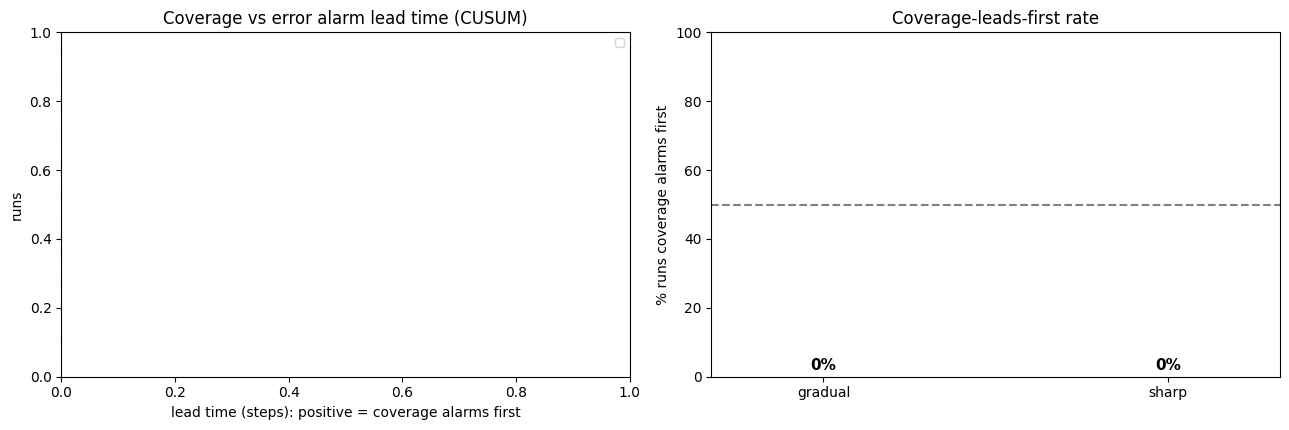

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(13,4.4))
for mode,col in [("sharp","#264653"),("gradual","#e76f51")]:
    lead=M[(M["mode"]==mode)&M["cov_fired"]&M["err_fired"]]["lead"].dropna()
    if len(lead): ax[0].hist(lead,bins=25,alpha=0.6,label=f"{mode} (median {lead.median():.0f}, n={len(lead)})",color=col)
ax[0].axvline(0,ls="--",color="gray"); ax[0].set_xlabel("lead time (steps): positive = coverage alarms first")
ax[0].set_ylabel("runs"); ax[0].set_title("Coverage vs error alarm lead time (CUSUM)"); ax[0].legend(fontsize=8)
s=M.groupby("mode").apply(lambda d: 100*(d[d.cov_fired&d.err_fired]["lead"]>0).mean() if (d.cov_fired&d.err_fired).any() else 0)
ax[1].bar([str(i) for i in s.index],s.values,color=["#e76f51","#264653"],width=0.5)
ax[1].axhline(50,ls="--",color="gray"); ax[1].set_ylim(0,100); ax[1].set_ylabel("% runs coverage alarms first"); ax[1].set_title("Coverage-leads-first rate")
for i,v in enumerate(s.values): ax[1].text(i,v+2,f"{v:.0f}%",ha="center",fontsize=11,fontweight="bold")
fig.tight_layout(); fig.savefig(os.path.join(CFG["fig_dir"],"13_sequential_lead.png"),dpi=150,bbox_inches="tight"); plt.show()

In [ ]:
!git add reports/ figures/ notebooks/
!git commit -m "13 sequential monitoring v2: CUSUM change-detectors on coverage vs error, fairly matched; sharp + gradual entry; lead-time distribution"
!git push origin main

[main b3ef283] 13 sequential monitoring v2: CUSUM change-detectors on coverage vs error, fairly matched; sharp + gradual entry; lead-time distribution
 5 files changed, 47 insertions(+), 51 deletions(-)
 rewrite figures/13_sequential_lead.png (99%)
 rewrite notebooks/13_sequential_monitoring.ipynb (99%)
Enumerating objects: 19, done.
Counting objects: 100% (19/19), done.
Delta compression using up to 2 threads
Compressing objects: 100% (9/9), done.
Writing objects: 100% (10/10), 47.99 KiB | 2.00 MiB/s, done.
Total 10 (delta 5), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (5/5), completed with 5 local objects.
To https://github.com/anasbiswas1/uav-trust-research.git
   672aa0c..b3ef283  main -> main


In [3]:
from google.colab import drive
drive.mount('/content/drive')
import os
base = '/content/drive/MyDrive/UAV_TRUST_Research'
for root, dirs, files in os.walk(base):
    for f in files:
        if 'UAV-CAS' in f:
            print(os.path.join(root, f))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/UAV_TRUST_Research/uav-trust-research/data/uav_cas/UAV-CAS_stat.csv
/content/drive/MyDrive/UAV_TRUST_Research/uav-trust-research/data/uav_cas/UAV-CAS_ts.csv
